In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## EDA For Classification
### 주제 : 여러 피처들을 활용해 안정정지 여부 체크

### Cell 1: 불필요한 컬럼, 결측치 제거 및 & 통합 타겟 변수 System_Failure 생성

In [20]:
# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

# 컬럼명 변경 (Temperature_T0 -> Temperature_J0)
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)

# 불필요한 컬럼 제거 (Num, Timestamp,)
#df.drop(columns=['Num', 'Timestamp', 'cycle'], inplace=True, errors='ignore')
df.drop(columns=['Num', 'Timestamp'], inplace=True, errors='ignore')
# Target 변수 결측치 처리 및 이진 타겟 생성
df['Robot_ProtectiveStop'] = df['Robot_ProtectiveStop'].fillna(False).astype(bool).astype(int)
df['grip_lost'] = df['grip_lost'].fillna(False).astype(bool).astype(int)
df['System_Failure'] = ((df['Robot_ProtectiveStop'] == 1) | (df['grip_lost'] == 1)).astype(int)

# 결측치가 포함된 54개 행 제거 (Regression 기준 동일 적용)
df.dropna(inplace=True)

print(f"데이터셋 크기: {df.shape}")
display(df.head())

데이터셋 크기: (7355, 23)


,Current_J0,Temperature_J0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,...,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost,System_Failure
0,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,...,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0,0,0
1,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,...,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0,0,0
2,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,...,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0,0,0
3,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,...,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0,0,0
4,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,...,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0,0,0


### Cell 2: System_Failure 분포 확인

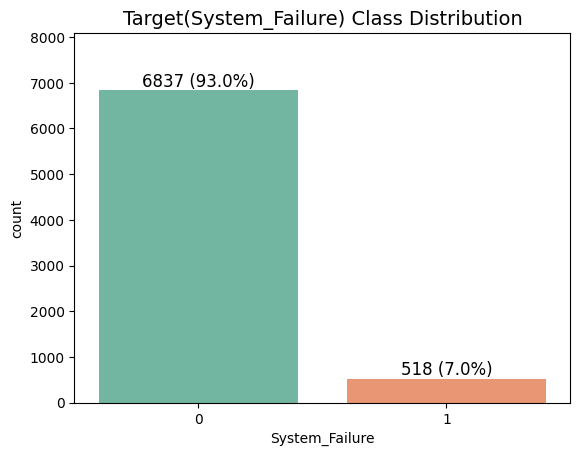

In [21]:
# 경고를 해결하기 위해 hue='System_Failure'와 legend=False를 추가했습니다.
ax = sns.countplot(data=df, x='System_Failure', hue='System_Failure', palette='Set2', legend=False)
plt.title('Target(System_Failure) Class Distribution', fontsize=14)

# 막대 위에 개수 및 비율 표시
total = len(df)
for p in ax.patches:
    count = p.get_height()
    # 빈도가 0인 범주에서 결측치 에러가 나는 것을 방지합니다.
    if count > 0:
        percentage = f'{100 * count / total:.1f}%'
        ax.annotate(f'{int(count)} ({percentage})',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)

plt.ylim(0, total * 1.1)
plt.show()

# 심한 불균형 (약 93:7)을 보임 -> 이후 모델링에서 SMOTE 같은 오버샘플링 필수

### Cell 3-1: Current 그룹별 타겟 비교

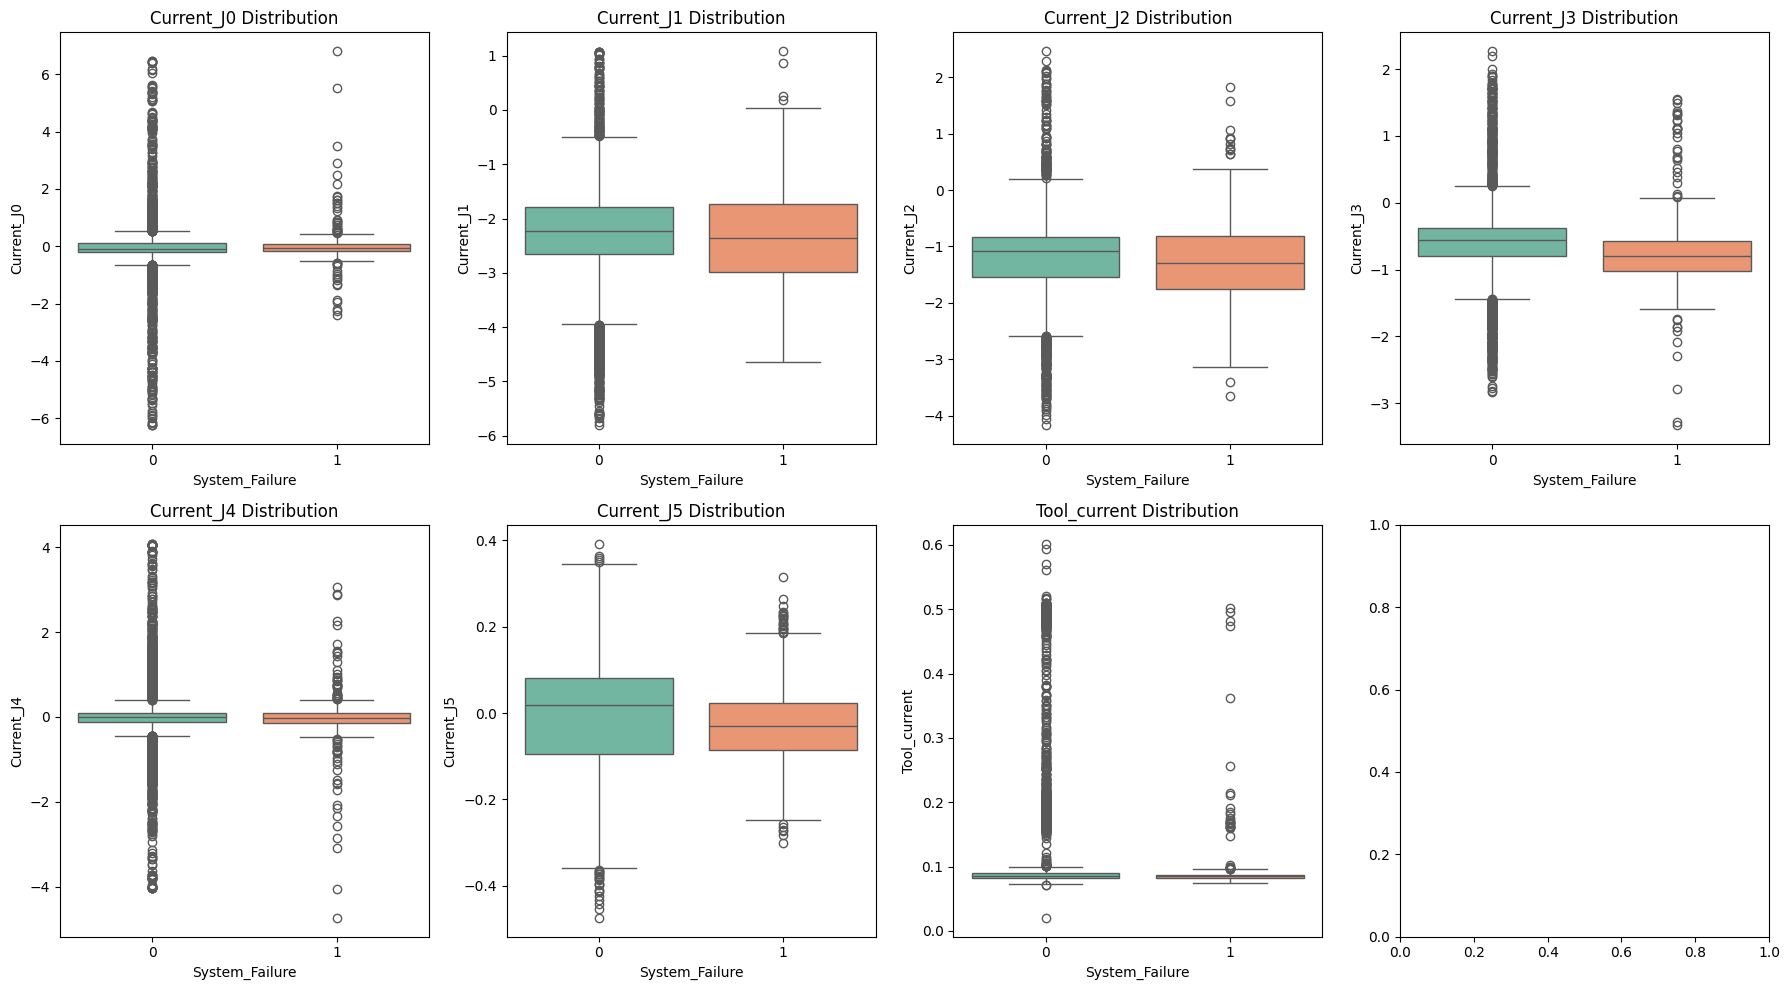

In [22]:
# 관절별 전류(Current)와 고장 여부의 관계
current_cols = [f'Current_J{i}' for i in range(6)] + ['Tool_current']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(current_cols):
    sns.boxplot(data=df, x='System_Failure', y=col, ax=axes[i], palette='Set2', hue='System_Failure', legend=False)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

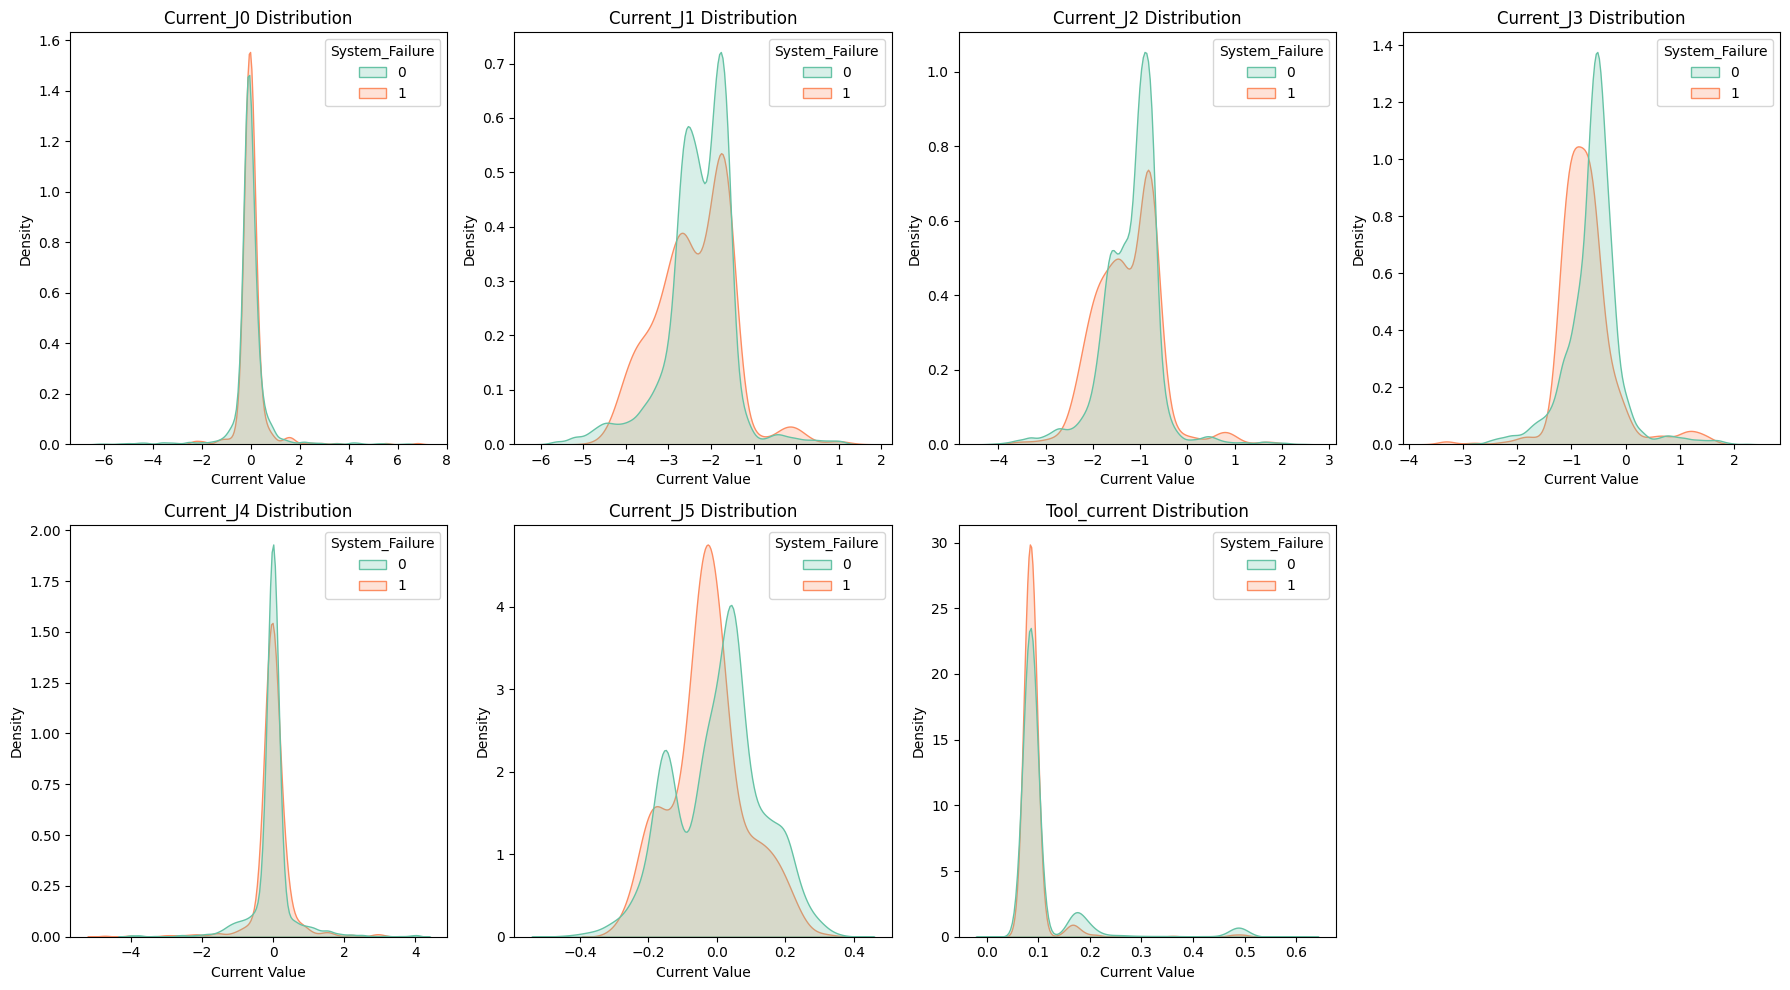

In [6]:
# 관절별 전류(Current)와 고장 여부의 관계
current_cols = [f'Current_J{i}' for i in range(6)] + ['Tool_current']

# 2행 4열 구조 유지 (마지막 8번째 칸은 빈칸으로 비워둠)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(current_cols):
    # boxplot 대신 kdeplot 사용 (fill=True로 곡선 아래 색상을 채움)
    sns.kdeplot(
        data=df,
        x=col,
        hue='System_Failure',
        fill=True,
        common_norm=False,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Current Value')
    axes[i].set_ylabel('Density')

# 데이터가 없는 마지막 8번째 서브플롯(axes[7])은 깔끔하게 숨김 처리
fig.delaxes(axes[7])

plt.tight_layout()

### Cell 3-2: Speed 그룹별 타겟 비교

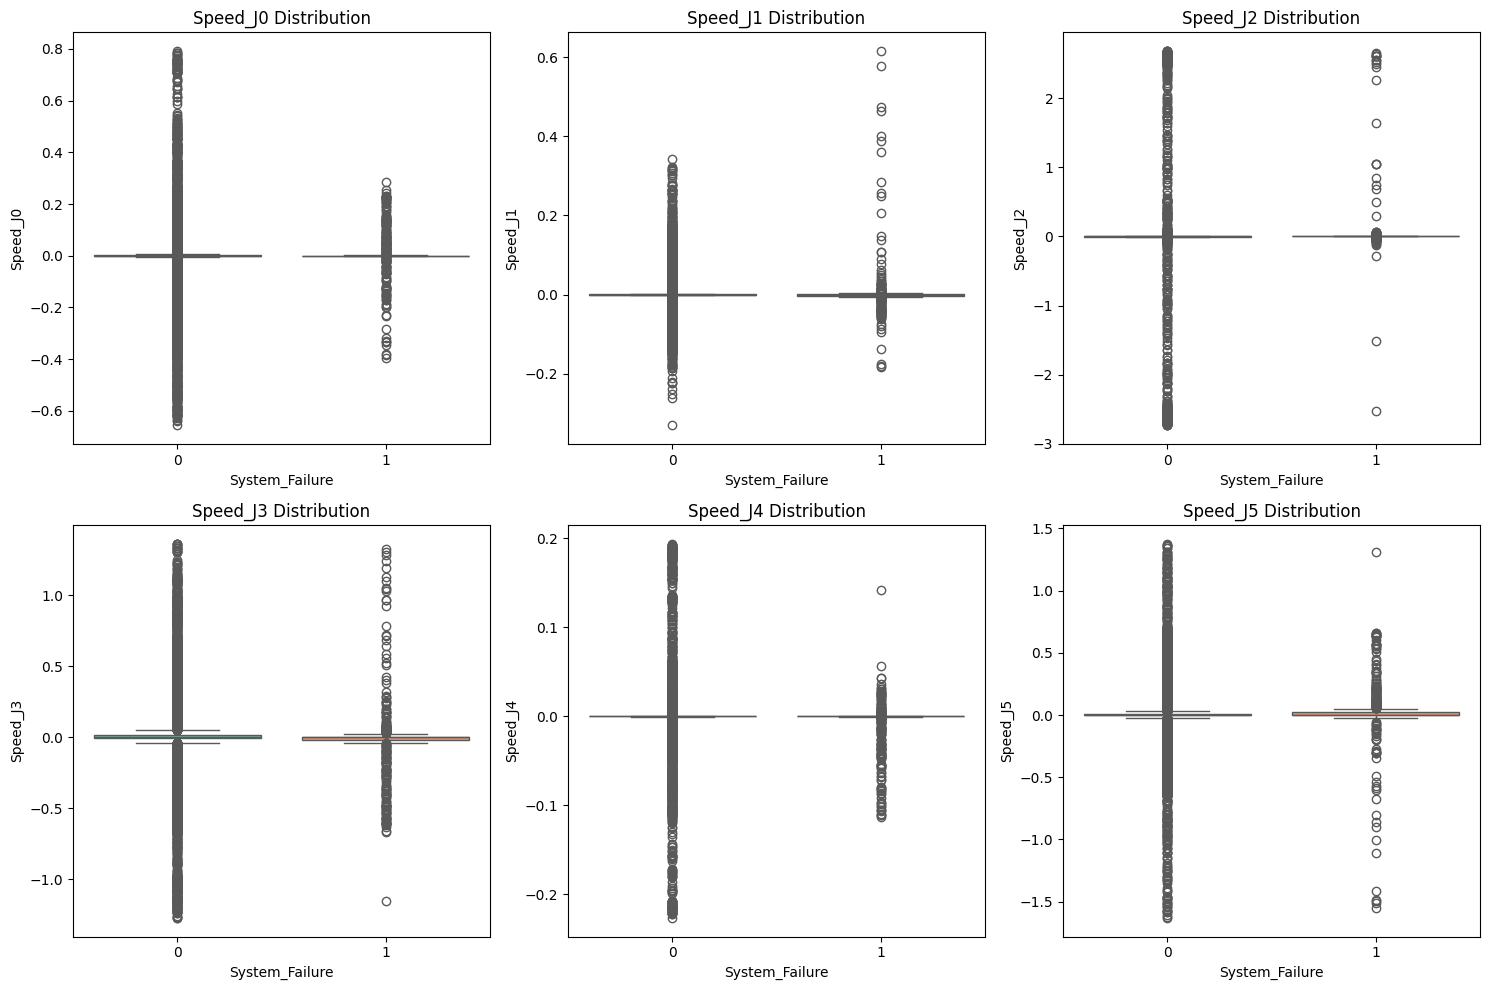

In [7]:
# 관절별 속도(Speed)와 고장 여부의 관계
speed_cols = [f'Speed_J{i}' for i in range(6)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(speed_cols):
    sns.boxplot(data=df, x='System_Failure', y=col, ax=axes[i], palette='Set2', hue='System_Failure', legend=False)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

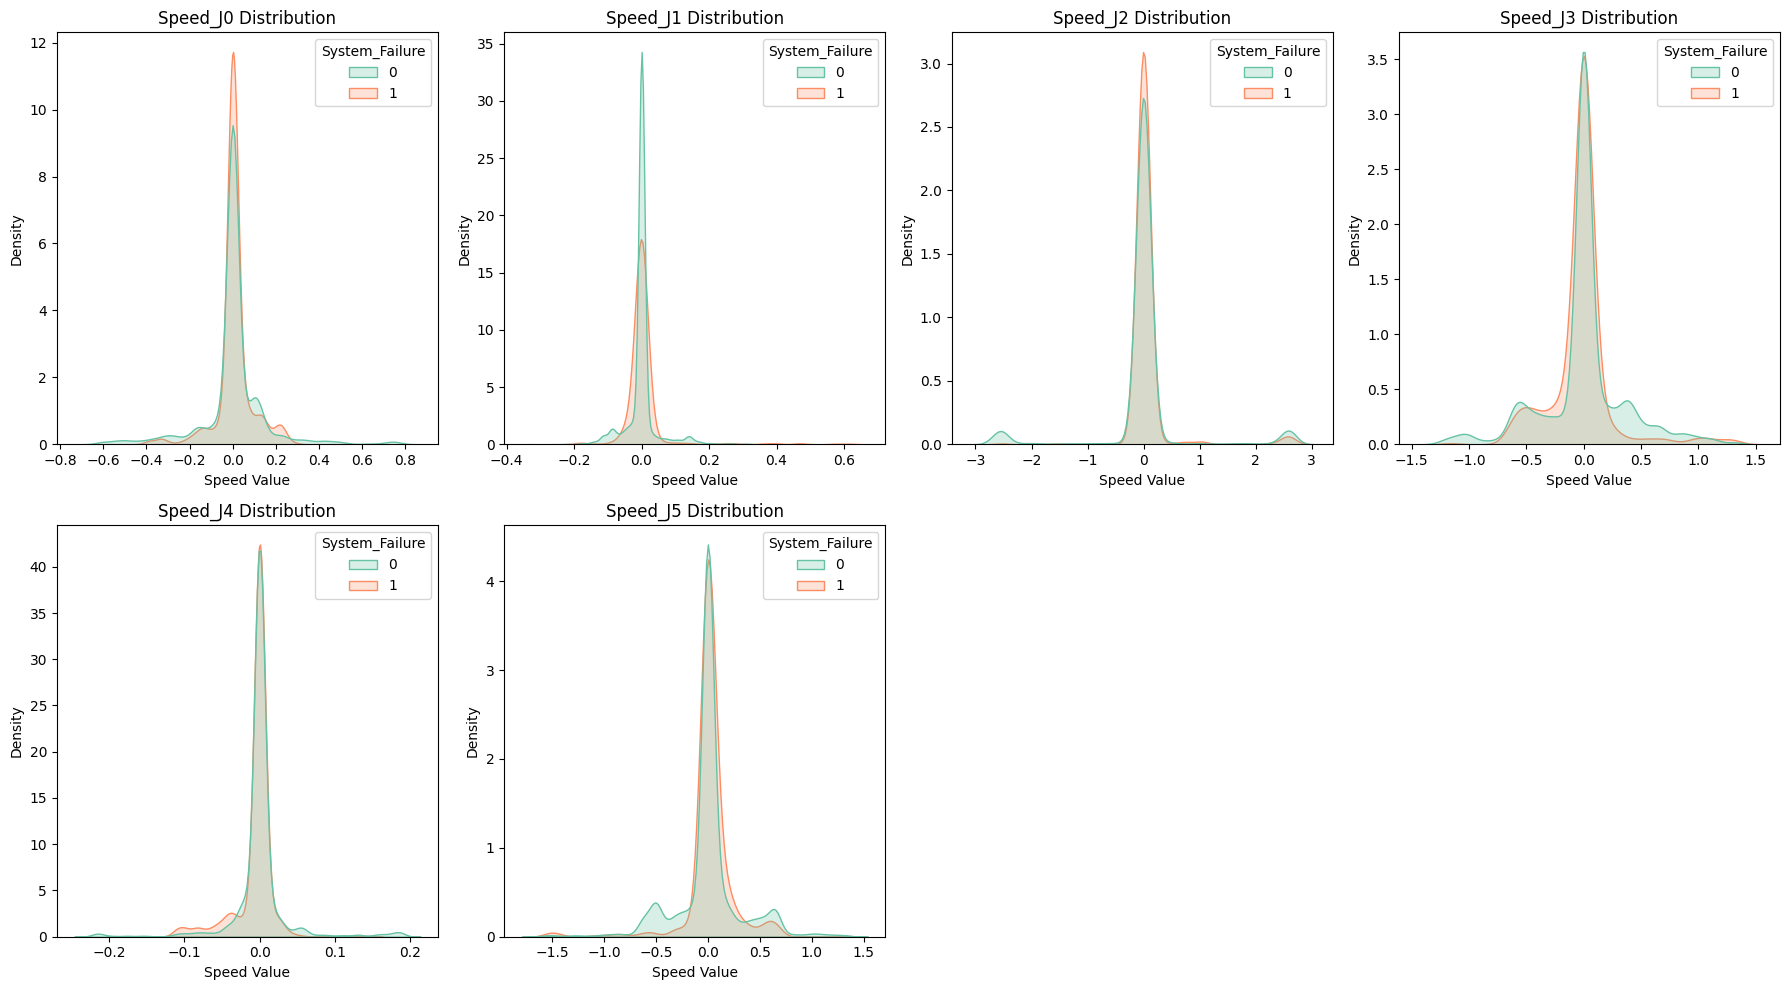

In [ ]:
# 관절별 속도와 고장 여부의 관계
Speed_cols = [f'Speed_J{i}' for i in range(6)]

# 2행 4열 구조 유지 (마지막 8번째 칸은 빈칸으로 비워둠)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(Speed_cols):
    # boxplot 대신 kdeplot 사용 (fill=True로 곡선 아래 색상을 채움)
    sns.kdeplot(
        data=df,
        x=col,
        hue='System_Failure',
        fill=True,
        common_norm=False,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Speed Value')
    axes[i].set_ylabel('Density')

# 데이터가 없는 마지막 8번째 서브플롯(axes[7])은 깔끔하게 숨김 처리
fig.delaxes(axes[6])
fig.delaxes(axes[7])

plt.tight_layout()

### Cell 3-3: Temperature 그룹별 타겟 비교

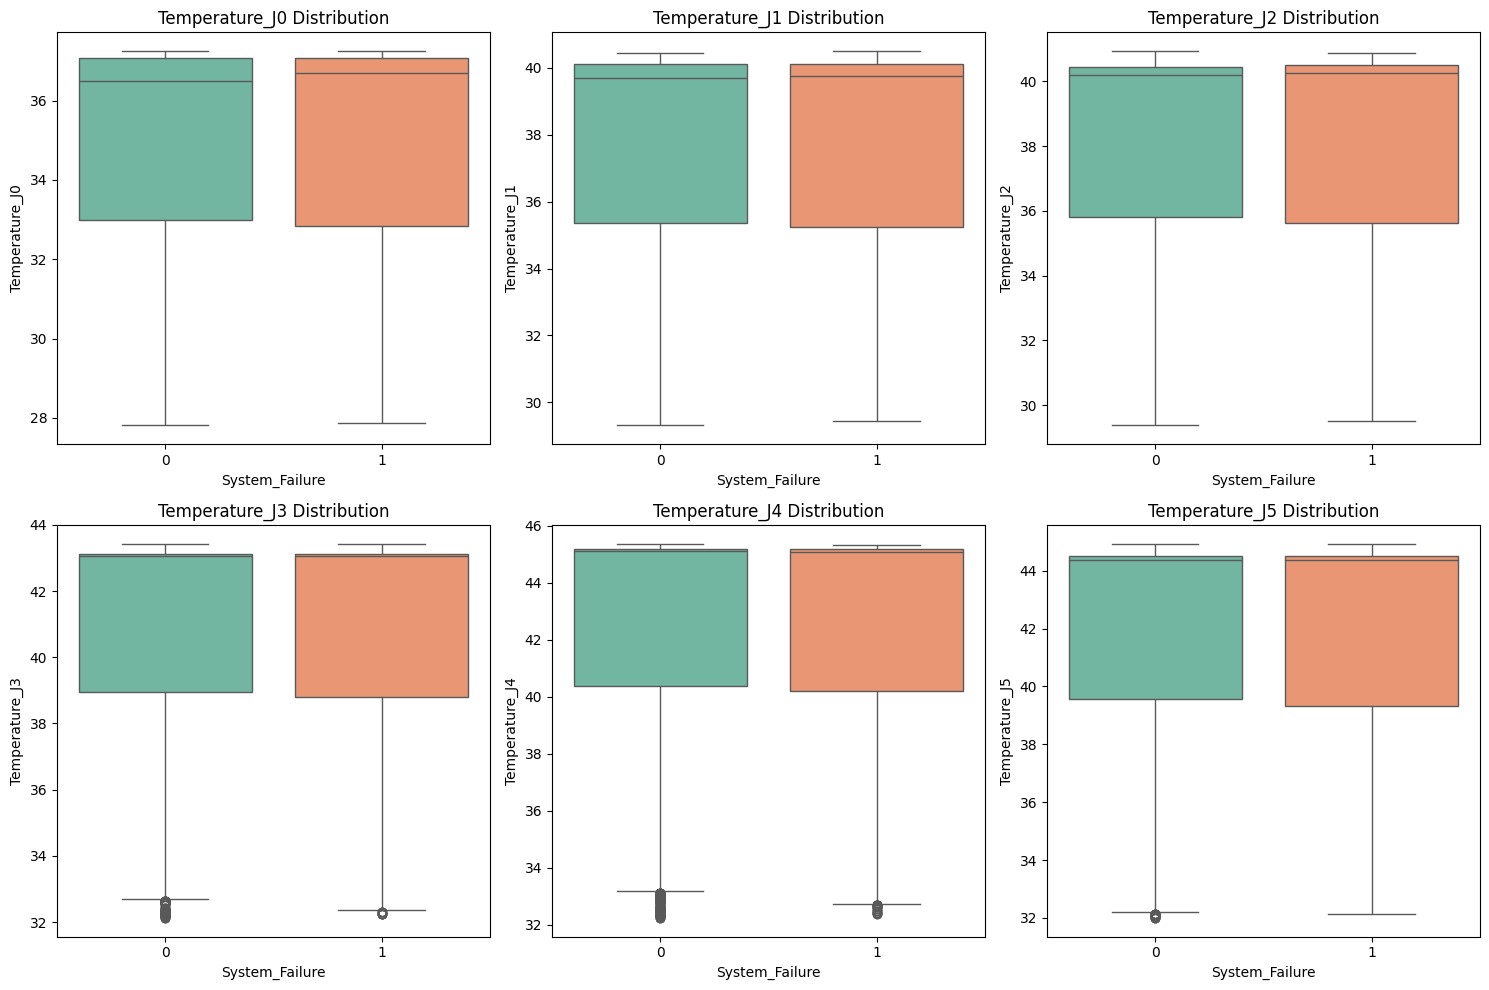

In [ ]:
# 관절별 온도(Temperature)와 고장 여부의 관계
temperature_cols = [f'Temperature_J{i}' for i in range(6)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(temperature_cols):
    sns.boxplot(data=df, x='System_Failure', y=col, ax=axes[i], palette='Set2', hue='System_Failure', legend=False)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

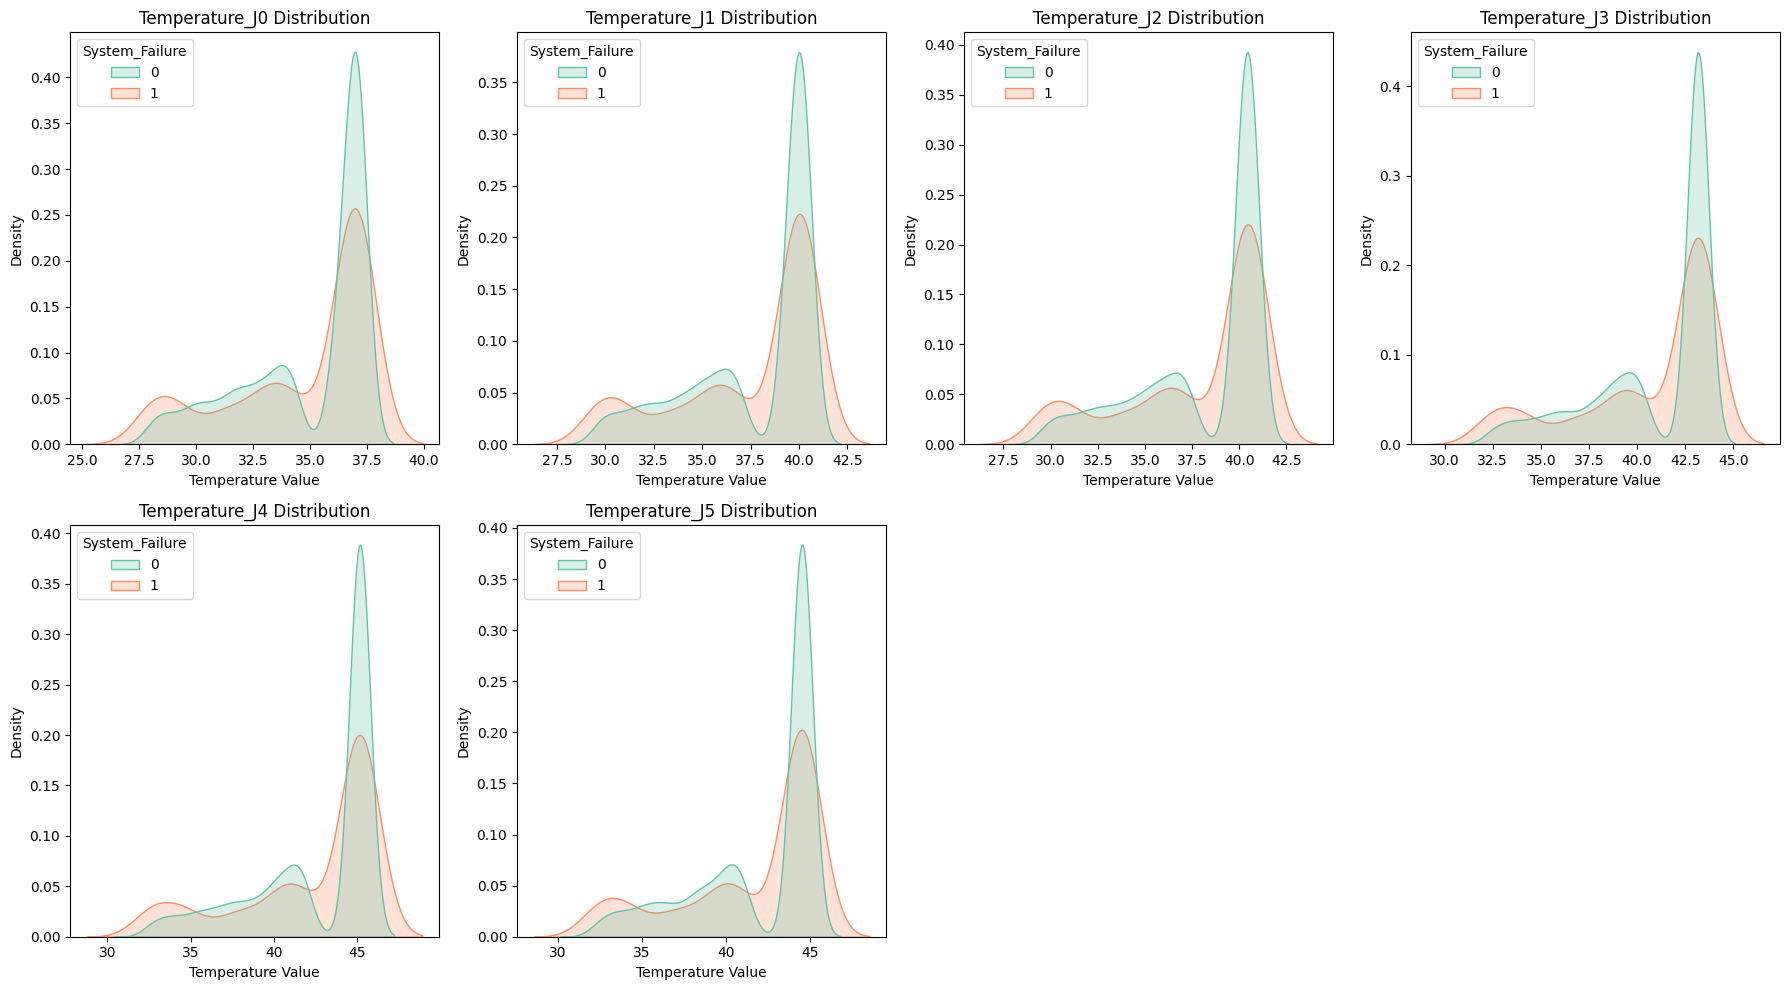

In [10]:
# 관절별 온도(Temperature)와 고장 여부의 관계
Temperature_cols = [f'Temperature_J{i}' for i in range(6)]

# 2행 4열 구조 유지 (마지막 8번째 칸은 빈칸으로 비워둠)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(Temperature_cols):
    # boxplot 대신 kdeplot 사용 (fill=True로 곡선 아래 색상을 채움)
    sns.kdeplot(
        data=df,
        x=col,
        hue='System_Failure',
        fill=True,
        common_norm=False,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Temperature Value')
    axes[i].set_ylabel('Density')

# 데이터가 없는 마지막 8번째 서브플롯(axes[7])은 깔끔하게 숨김 처리
fig.delaxes(axes[6])
fig.delaxes(axes[7])

plt.tight_layout()

### Cell 4: 피처 간 상관관계 히트맵

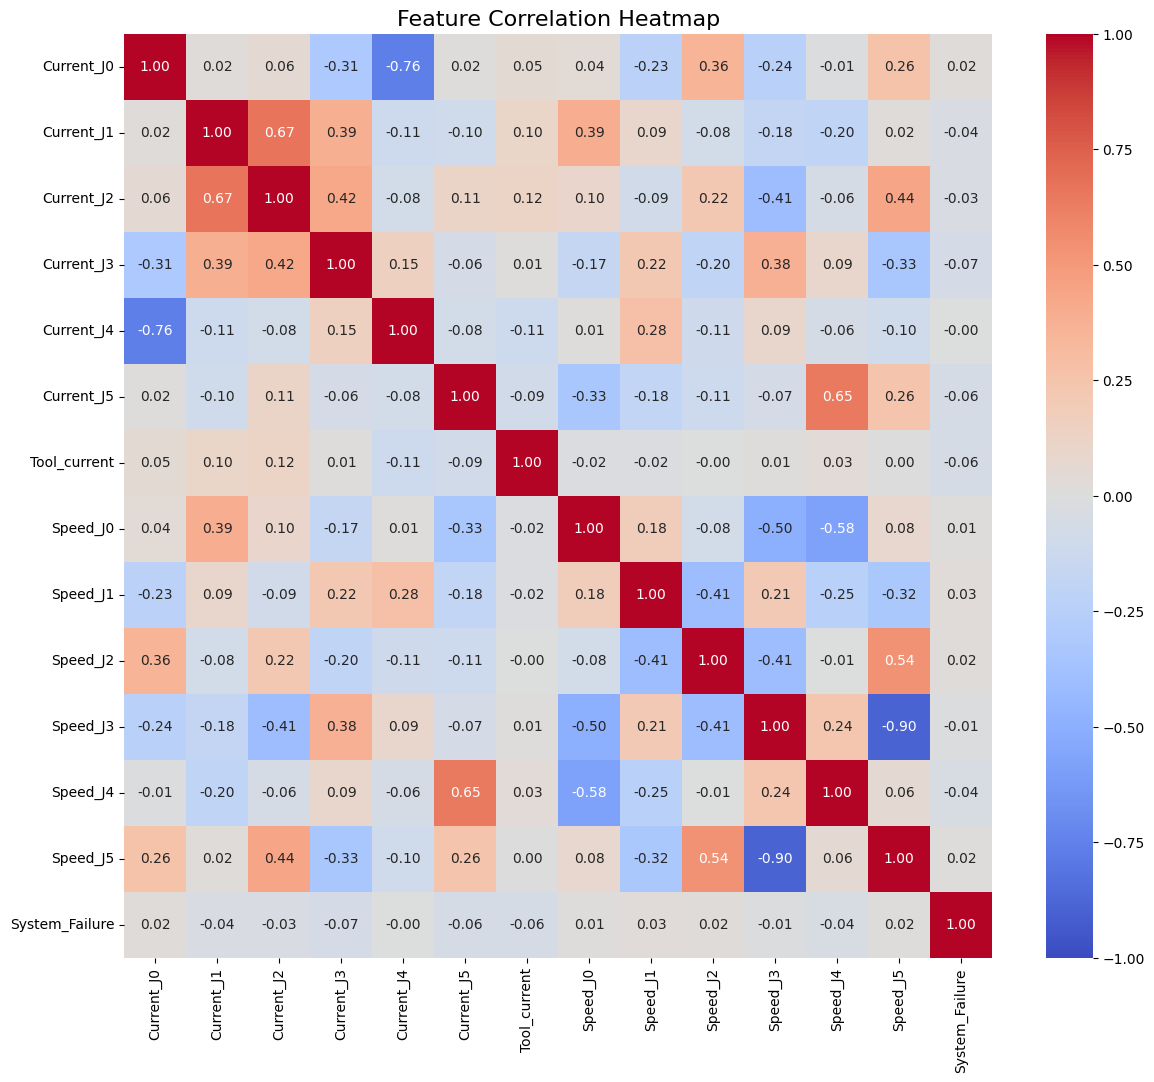

In [12]:
# 기본 센서 피처 및 타겟
base_cols = current_cols + speed_cols
corr_cols = base_cols + ['System_Failure']

# 상관계수 계산
corr_matrix = df[corr_cols].corr()

# 타겟과의 상관계수만 추출하여 정렬
target_corr = corr_matrix['System_Failure'].drop('System_Failure').sort_values(ascending=False)

# 전체 히트맵 시각화
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

In [13]:
# 타겟과 가장 높은 상관관계를 가지는 변수 Top 5
print("=== Target(System_Failure)과 상관관계 Top 5 ===")
print(target_corr.head(5))
print("\n=== Target(System_Failure)과 상관관계 Bottom 5 ===")
print(target_corr.tail(5))

=== Target(System_Failure)과 상관관계 Top 5 ===
Speed_J1      0.027217
Speed_J2      0.022813
Current_J0    0.021893
Speed_J5      0.015012
Speed_J0      0.009371
Name: System_Failure, dtype: float64

=== Target(System_Failure)과 상관관계 Bottom 5 ===
Current_J1     -0.036154
Speed_J4       -0.041469
Current_J5     -0.060282
Tool_current   -0.060638
Current_J3     -0.065035
Name: System_Failure, dtype: float64


### Cell 5: 물리 기반 파생 변수(Feature Engineering) 유효성 검증

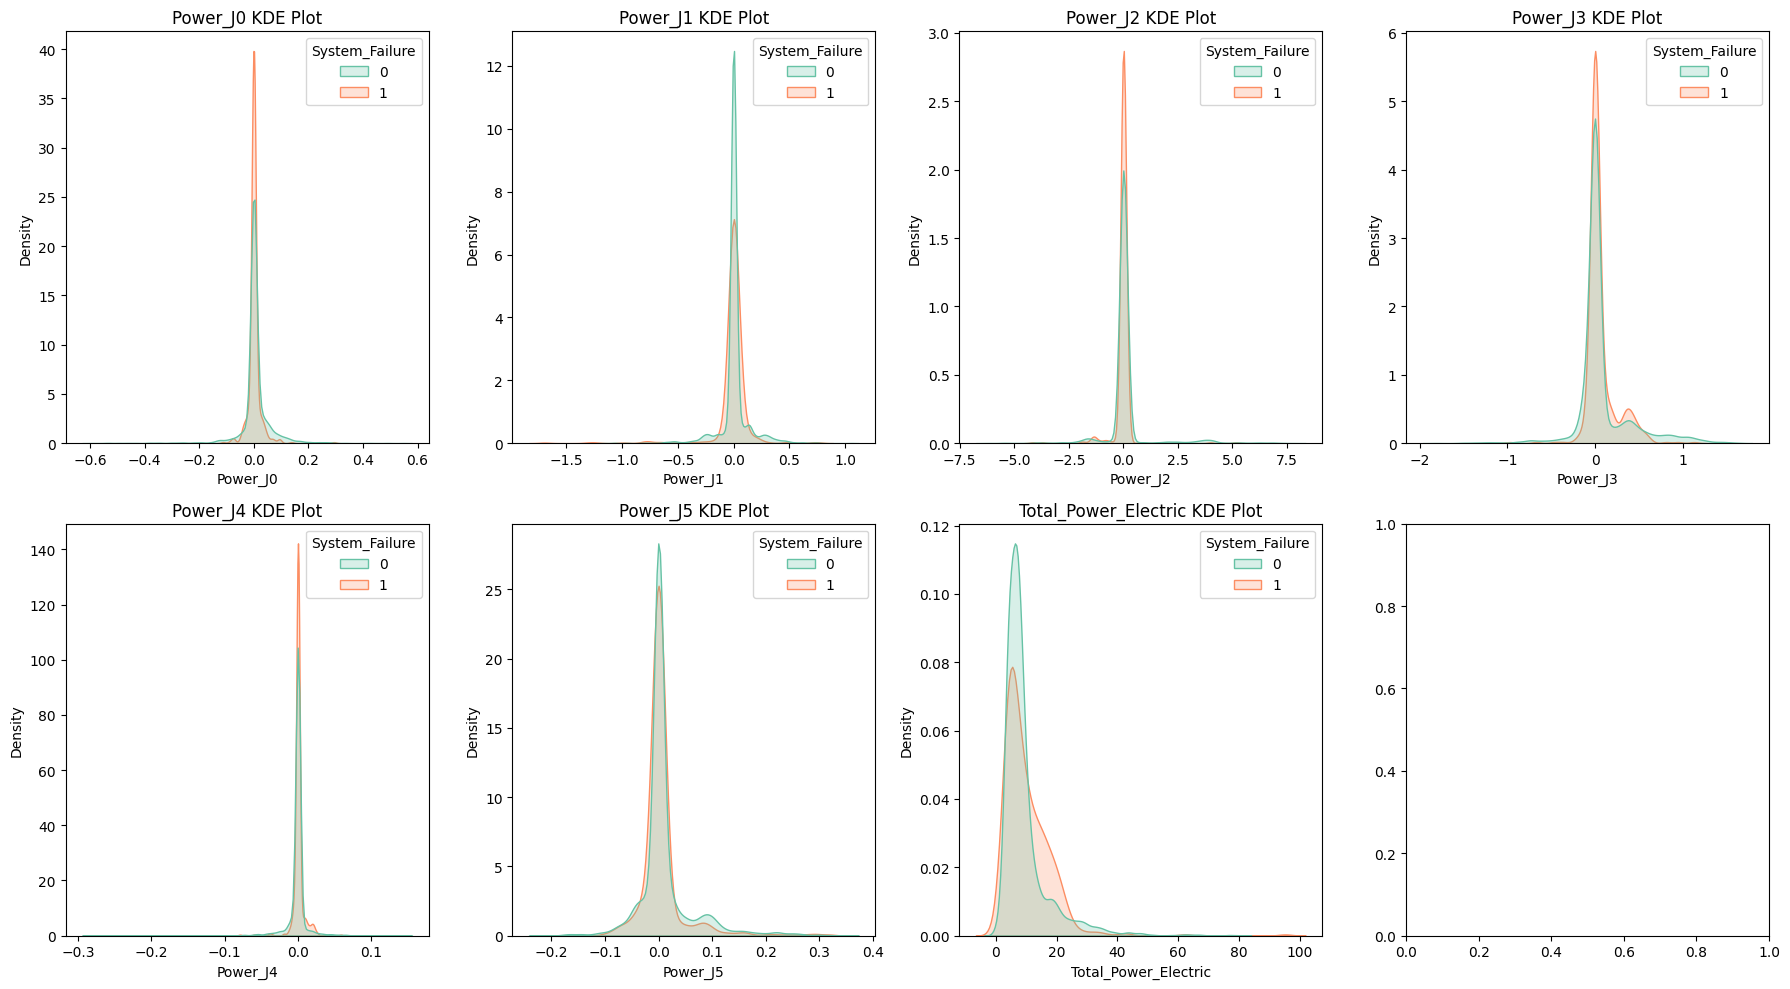

In [14]:
# 파생 변수 생성
for i in range(6):
    df[f'Power_J{i}'] = df[f'Current_J{i}'] * df[f'Speed_J{i}']

# 벡터화를 사용한 빠른 연산 적용
df['Total_Power_Electric'] = (df[current_cols]**2).sum(axis=1)

power_cols = [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(power_cols):
    sns.kdeplot(data=df, x=col, hue='System_Failure', fill=True, common_norm=False, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} KDE Plot')

plt.tight_layout()
plt.show()

### Cell 6: 사이클 관점의 고장 패턴 시각화 (Time-Series)

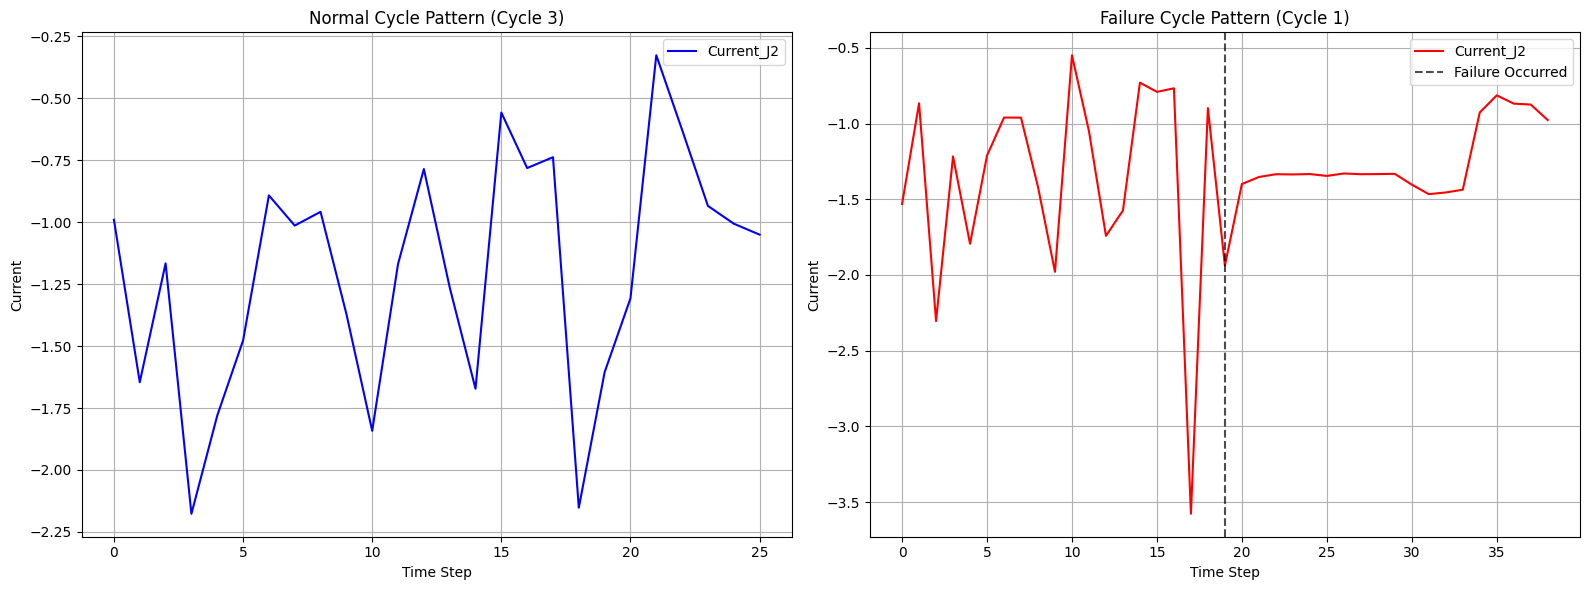

In [23]:
# 각 사이클별 타겟 발생 여부 요약
cycle_summary = df.groupby('cycle')['System_Failure'].max()

normal_cycles = cycle_summary[cycle_summary == 0].index
failure_cycles = cycle_summary[cycle_summary == 1].index

# 대표 사이클 선택
sample_normal = df[df['cycle'] == normal_cycles[0]].reset_index(drop=True)
sample_failure = df[df['cycle'] == failure_cycles[0]].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 정상 사이클 (Current_J2 시각화 예시)
axes[0].plot(sample_normal.index, sample_normal['Current_J2'], color='blue', label='Current_J2')
axes[0].set_title(f'Normal Cycle Pattern (Cycle {normal_cycles[0]})')
axes[0].set_ylabel('Current')
axes[0].set_xlabel('Time Step')
axes[0].grid(True)
axes[0].legend()

# 고장 사이클
axes[1].plot(sample_failure.index, sample_failure['Current_J2'], color='red', label='Current_J2')
# 고장 발생 시점 수직선 표시
failure_points = sample_failure[sample_failure['System_Failure'] == 1].index
if len(failure_points) > 0:
    axes[1].axvline(x=failure_points[0], color='black', linestyle='--', alpha=0.7, label='Failure Occurred')
    
axes[1].set_title(f'Failure Cycle Pattern (Cycle {failure_cycles[0]})')
axes[1].set_ylabel('Current')
axes[1].set_xlabel('Time Step')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()